# 1. Research question

I have already seen from the spatial-dependence experiments that breach locations are not fully described by distance alone. Here I want to test whether representing the breach locations explicitly as a **graph** gives the model a better way to use that structure.

I treat each breach location as a node. The node features describe the location and breach characteristics, while the edges describe relationships between locations:

- **Nodes:** breach locations
- **Node features:** geographic position and breach characteristics
- **Edges:** spatial proximity, shared river, and shared dike ring
- **Target:** log flood damage

My main question is whether this explicit graph representation adds useful information for predicting flood-scenario severity, especially when the same breach location appears across different return periods.


## 2. Imports & paths

I set up the data, results, and table paths here so that the graph construction and later outputs use the same project structure as the earlier notebooks.


In [2]:
import numpy as np
import pandas as pd

from pathlib import Path

ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load the processed catalogue

I start from the processed LIWO scenario catalogue created in the earlier reconstruction work. At this stage I am not rebuilding the raw data; I am using the cleaned catalogue as the common input for the graph experiments below.


In [3]:
scenario_path = (
    DATA_DIR
    / "processed"
    / "liwo_scenario_catalog.csv"
)

df = pd.read_csv(scenario_path)

df["damage_MEUR_num"] = pd.to_numeric(
    df["damage_MEUR"],
    errors="coerce"
)

df["return_period"] = pd.to_numeric(
    df["return_period"],
    errors="coerce"
)

df["log_damage"] = np.log1p(
    df["damage_MEUR_num"]
)

print("Rows:", len(df))

Rows: 1856


## 4. Reconstruct the graph population

For the graph I need one consistent set of breach locations. I therefore restrict the population to locations for which the information needed for the experiment is available.

This is deliberately a location-level graph: the nodes represent breach locations, while return period remains part of the prediction target rather than creating a separate node for every scenario.


In [8]:
scenario_path = (
    DATA_DIR
    / "processed"
    / "liwo_scenario_catalog.csv"
)

df = pd.read_csv(scenario_path)

df["damage_MEUR_num"] = pd.to_numeric(
    df["damage_MEUR"],
    errors="coerce"
)

df["return_period"] = pd.to_numeric(
    df["return_period"],
    errors="coerce"
)

df["log_damage"] = np.log1p(
    df["damage_MEUR_num"]
)

print("Rows:", len(df))

Rows: 1856


In [9]:
graph_data = df.dropna(
    subset=[
        "damage_MEUR_num",
        "log_damage",
        "geometry_x",
        "geometry_y",
        "river",
        "dijkring"
    ]
).copy()

# One row per breach location
nodes = (
    graph_data
    .groupby("breach_id", as_index=False)
    .agg(
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first"),
        river=("river", "first"),
        dijkring=("dijkring", "first"),
        breach_name=("breach_name", "first"),
        initial_breach_width=(
            "initial_breach_width",
            "first"
        ),
        breach_growth_method=(
            "breach_growth_method",
            "first"
        )
    )
)

print("Graph nodes:", len(nodes))
print(nodes.head())

Graph nodes: 610
   breach_id  geometry_x  geometry_y                river  \
0          1       63661      394660        Oosterschelde   
1         14      153030      421657                 Maas   
2         25      157861      425941                 Maas   
3        185      122028      487923       Noordzeekanaal   
4        191      194414      436878  Pannerdensch kanaal   

                                            dijkring           breach_name  \
0            Dijkring 27 - Tholen en St. Philipsland  20a_Extrabreslocatie   
1                                 Dijkring 39 - Alem                  Alem   
2                Dijkring 41 - Land van Maas en Waal                Alphen   
3                          Dijkring 44 - Kromme Rijn        Amsterdam zuid   
4  Dijkring 43 - Betuwe, Tieler- en Culemborgerwaard            AngerenARK   

  initial_breach_width breach_growth_method  
0                 10,0          automatisch  
1               -999,0                       
2        

In [10]:
node_scenarios = (
    graph_data
    .groupby(
        ["breach_id", "return_period"],
        as_index=False
    )
    .agg(
        log_damage=("log_damage", "mean")
    )
)

node_scenarios = node_scenarios[
    node_scenarios["breach_id"].isin(
        nodes["breach_id"]
    )
].copy()

print(
    "Location × return-period observations:",
    len(node_scenarios)
)

print(
    "Locations:",
    node_scenarios["breach_id"].nunique()
)

Location × return-period observations: 1765
Locations: 610


## 5. Build graph edges

I use two kinds of relationships here.

First, I connect nearby breach locations so that the graph can represent local spatial influence. Second, I add links for locations that share the same river or dike ring, because those relationships may represent system structure that simple geographic distance does not capture.

I want to test whether this combination gives the GNN a more meaningful representation of the flood-defence system than distance alone.


In [11]:
coords = nodes[
    ["geometry_x", "geometry_y"]
].to_numpy()

n_nodes = len(nodes)

distance_matrix = np.sqrt(
    (
        (
            coords[:, None, :]
            - coords[None, :, :]
        ) ** 2
    ).sum(axis=2)
)

edges = []

k = 5

for i in range(n_nodes):

    nearest = np.argsort(
        distance_matrix[i]
    )[1:k+1]

    for j in nearest:

        distance_km = (
            distance_matrix[i, j] / 1000
        )

        edges.append({
            "source": i,
            "target": j,
            "distance_km": distance_km,
            "same_river": int(
                nodes.iloc[i]["river"]
                == nodes.iloc[j]["river"]
            ),
            "same_dijkring": int(
                nodes.iloc[i]["dijkring"]
                == nodes.iloc[j]["dijkring"]
            )
        })

edges = pd.DataFrame(edges)

print("Directed spatial edges:", len(edges))
print(edges.head())

Directed spatial edges: 3050
   source  target  distance_km  same_river  same_dijkring
0       0     379     0.170575           1              1
1       0     378     1.175838           1              1
2       0     307     3.641577           1              1
3       0     320     3.746939           1              0
4       0     321     3.956414           1              0


In [12]:
system_edges = []

for i in range(n_nodes):

    for j in range(i + 1, n_nodes):

        same_river = int(
            nodes.iloc[i]["river"]
            == nodes.iloc[j]["river"]
        )

        same_dijkring = int(
            nodes.iloc[i]["dijkring"]
            == nodes.iloc[j]["dijkring"]
        )

        if same_river or same_dijkring:

            system_edges.append({
                "source": i,
                "target": j,
                "distance_km":
                    distance_matrix[i, j] / 1000,
                "same_river": same_river,
                "same_dijkring": same_dijkring
            })

            system_edges.append({
                "source": j,
                "target": i,
                "distance_km":
                    distance_matrix[i, j] / 1000,
                "same_river": same_river,
                "same_dijkring": same_dijkring
            })

system_edges = pd.DataFrame(
    system_edges
)

print(
    "Directed system edges:",
    len(system_edges)
)

Directed system edges: 25578


### Before training: inspect the graph

Before fitting a model, I inspect the resulting graph rather than assuming that the topology is sensible. I want to know how many connections it contains, whether different edge types overlap, and whether the graph is numerically well formed.

This check matters because an error in the graph construction would affect every later GNN result.


In [13]:
all_edges = pd.concat(
    [edges, system_edges],
    ignore_index=True
)

all_edges = (
    all_edges
    .drop_duplicates(
        subset=[
            "source",
            "target"
        ]
    )
    .reset_index(drop=True)
)

print("Final directed edges:", len(all_edges))

print("\nEdge properties:")
print(
    all_edges[
        [
            "distance_km",
            "same_river",
            "same_dijkring"
        ]
    ].describe()
)

Final directed edges: 25956

Edge properties:
        distance_km    same_river  same_dijkring
count  25956.000000  25956.000000   25956.000000
mean      29.985368      0.752119       0.434119
std       39.267367      0.431791       0.495650
min        0.018439      0.000000       0.000000
25%        9.102387      1.000000       0.000000
50%       16.677364      1.000000       0.000000
75%       31.452548      1.000000       1.000000
max      286.850170      1.000000       1.000000


In [14]:
nodes.to_csv(
    TABLE_DIR / "graph_nodes.csv",
    index=False
)

all_edges.to_csv(
    TABLE_DIR / "graph_edges.csv",
    index=False
)

node_scenarios.to_csv(
    TABLE_DIR / "graph_node_scenarios.csv",
    index=False
)

print("Graph data saved.")

Graph data saved.


## Inspect edge-type overlap and distances

I look at the overlap between spatial, river, and dike-ring relationships and at the distances represented by the edges.

The purpose is not yet to prove dependence. I am checking whether the graph actually contains the different kinds of relationships I intended to encode and whether the edge design creates any obvious imbalance.


In [15]:
edge_type_counts = (
    all_edges.assign(
        edge_type=np.select(
            [
                (all_edges["same_river"] == 1) &
                (all_edges["same_dijkring"] == 1),
                all_edges["same_river"] == 1,
                all_edges["same_dijkring"] == 1
            ],
            [
                "same_river_and_dijkring",
                "same_river_only",
                "same_dijkring_only"
            ],
            default="spatial_only"
        )
    )
    .groupby("edge_type")
    .size()
    .sort_values(ascending=False)
)

edge_type_counts

edge_type
same_river_only            14310
same_dijkring_only          6056
same_river_and_dijkring     5212
spatial_only                 378
dtype: int64

In [16]:
edge_type_distance = (
    all_edges.assign(
        edge_type=np.select(
            [
                (all_edges["same_river"] == 1) &
                (all_edges["same_dijkring"] == 1),
                all_edges["same_river"] == 1,
                all_edges["same_dijkring"] == 1
            ],
            [
                "same_river_and_dijkring",
                "same_river_only",
                "same_dijkring_only"
            ],
            default="spatial_only"
        )
    )
    .groupby("edge_type")
    .agg(
        n_edges=("distance_km", "size"),
        median_distance_km=("distance_km", "median"),
        mean_distance_km=("distance_km", "mean"),
        max_distance_km=("distance_km", "max")
    )
    .sort_values("n_edges", ascending=False)
)

edge_type_distance

,n_edges,median_distance_km,mean_distance_km,max_distance_km
edge_type,,,,
same_river_only,14310,20.718724,39.166826,286.850170
same_dijkring_only,6056,15.955408,23.751516,129.402908
same_river_and_dijkring,5212,9.250077,13.790238,119.103576
spatial_only,378,4.414466,5.579488,28.964221


## Build normalized edge weights

The raw distances and binary system indicators are on different scales, so I convert them into a common edge representation.

I use an exponential distance decay to give closer locations a larger spatial weight, while retaining the river and dike-ring indicators separately. The 25 km length scale is a modelling choice for this prototype, not a calibrated physical constant.


In [17]:
graph_edges = all_edges.copy()

# Distance decay for local spatial influence
graph_edges["distance_weight"] = np.exp(
    -graph_edges["distance_km"] / 25.0
)

# Relationship indicators
graph_edges["same_river_weight"] = (
    graph_edges["same_river"].astype(float)
)

graph_edges["same_dijkring_weight"] = (
    graph_edges["same_dijkring"].astype(float)
)

print(
    graph_edges[
        [
            "distance_km",
            "distance_weight",
            "same_river",
            "same_dijkring"
        ]
    ].describe()
)

        distance_km  distance_weight    same_river  same_dijkring
count  25956.000000     25956.000000  25956.000000   25956.000000
mean      29.985368         0.485014      0.752119       0.434119
std       39.267367         0.268324      0.431791       0.495650
min        0.018439         0.000010      0.000000       0.000000
25%        9.102387         0.284193      1.000000       0.000000
50%       16.677364         0.513197      1.000000       0.000000
75%       31.452548         0.694825      1.000000       1.000000
max      286.850170         0.999263      1.000000       1.000000


In [18]:
graph_edges["edge_type"] = np.select(
    [
        (graph_edges["same_river"] == 1) &
        (graph_edges["same_dijkring"] == 1),

        graph_edges["same_river"] == 1,

        graph_edges["same_dijkring"] == 1
    ],
    [
        "same_river_and_dijkring",
        "same_river_only",
        "same_dijkring_only"
    ],
    default="spatial_only"
)

edge_weight_summary = (
    graph_edges
    .groupby("edge_type")
    .agg(
        n_edges=("distance_weight", "size"),
        median_distance_km=("distance_km", "median"),
        median_distance_weight=(
            "distance_weight",
            "median"
        ),
        mean_distance_weight=(
            "distance_weight",
            "mean"
        )
    )
    .sort_values("n_edges", ascending=False)
)

edge_weight_summary

,n_edges,median_distance_km,median_distance_weight,mean_distance_weight
edge_type,,,,
same_river_only,14310,20.718724,0.436595,0.413960
same_dijkring_only,6056,15.955408,0.528234,0.490157
same_river_and_dijkring,5212,9.250077,0.690732,0.650547
spatial_only,378,4.414466,0.838133,0.810062


In [20]:
import networkx as nx

G = nx.Graph()

G.add_nodes_from(range(len(nodes)))

for _, edge in graph_edges.iterrows():
    G.add_edge(
        int(edge["source"]),
        int(edge["target"])
    )

components = list(
    nx.connected_components(G)
)

component_sizes = sorted(
    [len(c) for c in components],
    reverse=True
)

print("Number of connected components:", len(components))
print("Largest component:", component_sizes[0])
print("Smallest component:", component_sizes[-1])
print("Component sizes:", component_sizes[:20])

Number of connected components: 1
Largest component: 610
Smallest component: 610
Component sizes: [610]


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.7.1+cu118
CUDA: True


## Build clean node-level features for the GNN

I now prepare the static information attached to each breach location.

Because the source catalogue contains missing or differently formatted breach-width fields, I clean those variables before encoding them. I also keep missingness indicators where appropriate rather than silently treating missing information as a real zero.


In [ ]:



# Clean breach width fields
for col in [
    "initial_breach_width",
    "max_breach_width"
]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Convert sentinel values to missing
df.loc[
    df["initial_breach_width"].isin([-999, -9999]),
    "initial_breach_width"
] = np.nan

df.loc[
    df["max_breach_width"].isin([-9999]),
    "max_breach_width"
] = np.nan

# Initial-width missingness
df["initial_width_missing"] = (
    df["initial_breach_width"]
    .isna()
    .astype(int)
)

# Median imputation
initial_width_median = (
    df["initial_breach_width"].median()
)

df["initial_breach_width_filled"] = (
    df["initial_breach_width"]
    .fillna(initial_width_median)
)

# Growth-method missingness
df["growth_method_missing"] = (
    df["breach_growth_method"]
    .isna()
    .astype(int)
)

df["breach_growth_method"] = (
    df["breach_growth_method"]
    .fillna("missing")
)

 
# Restrict to usable scenario observations


graph_data = df.dropna(
    subset=[
        "damage_MEUR_num",
        "log_damage",
        "geometry_x",
        "geometry_y",
        "river",
        "dijkring"
    ]
).copy()

 
# One row per breach location
 

node_features_df = (
    graph_data
    .groupby(
        "breach_id",
        as_index=False
    )
    .agg(
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first"),
        initial_breach_width_filled=(
            "initial_breach_width_filled",
            "first"
        ),
        initial_width_missing=(
            "initial_width_missing",
            "max"
        ),
        growth_method_missing=(
            "growth_method_missing",
            "max"
        ),
        river=("river", "first"),
        dijkring=("dijkring", "first"),
        breach_growth_method=(
            "breach_growth_method",
            "first"
        )
    )
)

# Match the exact node ordering already used by `nodes`
node_features_df = (
    nodes[["breach_id"]]
    .merge(
        node_features_df,
        on="breach_id",
        how="left"
    )
)

print("Graph nodes:", len(node_features_df))
print("Missing values:")
print(node_features_df.isna().sum())

Graph nodes: 610
Missing values:
breach_id                      0
geometry_x                     0
geometry_y                     0
initial_breach_width_filled    0
initial_width_missing          0
growth_method_missing          0
river                          0
dijkring                       0
breach_growth_method           0
dtype: int64


## Encode node features

The GNN needs numerical node features, so I encode the continuous variables and categorical descriptors into a model-ready representation.

I keep the geographic and breach-characteristic information at the node level because these describe properties of the breach location itself. The relationships between locations remain in the graph edges.


In [31]:
numeric_node_features = [
    "geometry_x",
    "geometry_y",
    "initial_breach_width_filled",
    "initial_width_missing",
    "growth_method_missing"
]

categorical_node_features = [
    "river",
    "dijkring",
    "breach_growth_method"
]

# Standardize numeric variables
scaler = StandardScaler()

X_num = scaler.fit_transform(
    node_features_df[numeric_node_features]
)

# One-hot categorical variables
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_cat = encoder.fit_transform(
    node_features_df[categorical_node_features]
)

X_nodes = np.hstack([
    X_num,
    X_cat
]).astype(np.float32)

print("Node feature matrix:", X_nodes.shape)

Node feature matrix: (610, 117)


## Build edge tensors

Here I convert the graph relationships into the tensors expected by PyTorch Geometric.

I keep distance weight, same-river, and same-dike-ring information as explicit edge attributes. This is important for the later edge-aware model: the graph topology alone tells the model *which* nodes are connected, while these attributes tell it *why* they are connected.


In [33]:
# Recreate edge attributes for the GNN
all_edges = all_edges.copy()

all_edges["distance_weight"] = np.exp(
    -all_edges["distance_km"] / 25.0
)

all_edges["same_river"] = (
    all_edges["same_river"]
    .astype(float)
)

all_edges["same_dijkring"] = (
    all_edges["same_dijkring"]
    .astype(float)
)

print(
    all_edges[
        [
            "source",
            "target",
            "distance_km",
            "distance_weight",
            "same_river",
            "same_dijkring"
        ]
    ].head()
)

print("\nMissing edge attributes:")
print(
    all_edges[
        [
            "distance_weight",
            "same_river",
            "same_dijkring"
        ]
    ].isna().sum()
)

   source  target  distance_km  distance_weight  same_river  same_dijkring
0       0     379     0.170575         0.993200         1.0            1.0
1       0     378     1.175838         0.954055         1.0            1.0
2       0     307     3.641577         0.864449         1.0            1.0
3       0     320     3.746939         0.860813         1.0            0.0
4       0     321     3.956414         0.853631         1.0            0.0

Missing edge attributes:
distance_weight    0
same_river         0
same_dijkring      0
dtype: int64


In [34]:
edge_index = torch.tensor(
    all_edges[
        ["source", "target"]
    ].to_numpy().T,
    dtype=torch.long
)

edge_attr = torch.tensor(
    all_edges[
        [
            "distance_weight",
            "same_river",
            "same_dijkring"
        ]
    ].to_numpy(),
    dtype=torch.float32
)

x_static = torch.tensor(
    X_nodes,
    dtype=torch.float32
)

print("Node features:", x_static.shape)
print("Edge index:", edge_index.shape)
print("Edge attributes:", edge_attr.shape)

Node features: torch.Size([610, 117])
Edge index: torch.Size([2, 25956])
Edge attributes: torch.Size([25956, 3])


## Check the graph object

Before training, I check the final graph object for the number of nodes and edges and verify that the node and edge tensors have the expected shapes.

I also check for invalid values because a malformed graph can otherwise produce a failure that looks like a modelling problem.


In [35]:
graph = Data(
    x=x_static,
    edge_index=edge_index,
    edge_attr=edge_attr
)

print(graph)
print("Nodes:", graph.num_nodes)
print("Edges:", graph.num_edges)
print("Node features:", graph.num_node_features)
print("Edge features:", graph.edge_attr.shape[1])

Data(x=[610, 117], edge_index=[2, 25956], edge_attr=[25956, 3])
Nodes: 610
Edges: 25956
Node features: 117
Edge features: 3


## Prepare return-period targets

Each breach location can appear under multiple return periods, so I keep the graph fixed and vary the return-period input when predicting the target.

This lets me ask a more specific question: given the same spatial/system graph, can the model combine return period with node and edge information to predict the corresponding flood damage?


In [36]:
return_periods = sorted(
    node_scenarios["return_period"]
    .dropna()
    .unique()
)

print("Return periods:", len(return_periods))
print(return_periods)

Return periods: 26
[np.int64(-9999), np.int64(50), np.int64(100), np.int64(125), np.int64(200), np.int64(400), np.int64(500), np.int64(1000), np.int64(1250), np.int64(2000), np.int64(4000), np.int64(5000), np.int64(9000), np.int64(10000), np.int64(12499), np.int64(12500), np.int64(20000), np.int64(40000), np.int64(100000), np.int64(125000), np.int64(199999), np.int64(200000), np.int64(400000), np.int64(928315), np.int64(1000000), np.int64(4000000)]


In [37]:
target_lookup = {}

for rp in return_periods:

    sub = node_scenarios[
        node_scenarios["return_period"] == rp
    ]

    target_lookup[rp] = dict(
        zip(
            sub["breach_id"],
            sub["log_damage"]
        )
    )

## Define the GNN

I start with an attention-based graph model because the problem is naturally relational: the prediction for one breach location can potentially benefit from information carried by neighbouring locations.

At this stage this is a modelling experiment, not an assumption that a GNN must outperform a tabular model. I will compare the results against the earlier benchmarks.


In [38]:
class FloodGNN(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4
    ):
        super().__init__()

        self.conv1 = GATv2Conv(
            input_dim,
            hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=3,
            add_self_loops=False
        )

        self.conv2 = GATv2Conv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            edge_dim=3,
            add_self_loops=False
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim + 1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        return_period
    ):

        h = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        h = self.conv2(
            h,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        # Log-transform return period
        rp_feature = torch.log1p(
            return_period
        ).reshape(-1, 1)

        h = torch.cat(
            [h, rp_feature],
            dim=1
        )

        return self.regressor(h).squeeze(-1)

## Test one forward pass

Before training, I run a single forward pass with a dummy return-period input.

This is a simple implementation check: I want to make sure the graph, node features, return-period input, and model output all have compatible shapes before spending time on training.


In [39]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = FloodGNN(
    input_dim=x_static.shape[1]
).to(device)

graph = graph.to(device)

dummy_rp = torch.full(
    (graph.num_nodes,),
    125,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    dummy_pred = model(
        graph.x,
        graph.edge_index,
        graph.edge_attr,
        dummy_rp
    )

print("Prediction shape:", dummy_pred.shape)
print("Device:", device)
print("Sample predictions:", dummy_pred[:5])

Prediction shape: torch.Size([610])
Device: cuda
Sample predictions: tensor([-0.3054, -0.2602, -0.2621, -0.3000, -0.2646], device='cuda:0')


## Train the GNN on Split 1

I first use one location-level train/test split to make sure the training procedure works end to end.

The split is by **breach location**, not by individual scenario row. This is important because the same location can occur at multiple return periods; a row-level random split could otherwise put the same breach location in both train and test and make the evaluation look better than it really is.


In [41]:
from sklearn.model_selection import GroupShuffleSplit

# Build the location × return-period target table
node_scenarios = (
    graph_data
    .groupby(
        ["breach_id", "return_period"],
        as_index=False
    )
    .agg(
        log_damage=("log_damage", "mean")
    )
)

node_scenarios = node_scenarios[
    node_scenarios["breach_id"].isin(
        nodes["breach_id"]
    )
].copy()

# Five identical-style location-level splits
gss = GroupShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

splits = list(
    gss.split(
        node_scenarios,
        groups=node_scenarios["breach_id"]
    )
)

for i, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):
    train_ids = set(
        node_scenarios.iloc[train_idx]["breach_id"]
    )
    test_ids = set(
        node_scenarios.iloc[test_idx]["breach_id"]
    )

    print(
        f"Split {i}: "
        f"train locations={len(train_ids)}, "
        f"test locations={len(test_ids)}, "
        f"overlap={len(train_ids & test_ids)}"
    )

Split 1: train locations=488, test locations=122, overlap=0
Split 2: train locations=488, test locations=122, overlap=0
Split 3: train locations=488, test locations=122, overlap=0
Split 4: train locations=488, test locations=122, overlap=0
Split 5: train locations=488, test locations=122, overlap=0


In [43]:
# Split 1: location-level holdout

train_idx, test_idx = splits[0]

train_location_ids = set(
    node_scenarios.iloc[train_idx]["breach_id"]
)

test_location_ids = set(
    node_scenarios.iloc[test_idx]["breach_id"]
)

print("Training locations:", len(train_location_ids))
print("Test locations:", len(test_location_ids))
print(
    "Location overlap:",
    len(train_location_ids & test_location_ids)
)

print(
    "Training observations:",
    len(node_scenarios.iloc[train_idx])
)

print(
    "Test observations:",
    len(node_scenarios.iloc[test_idx])
)

Training locations: 488
Test locations: 122
Location overlap: 0
Training observations: 1402
Test observations: 363


In [44]:
train_obs = node_scenarios[
    node_scenarios["breach_id"].isin(
        train_location_ids
    )
].copy()

test_obs = node_scenarios[
    node_scenarios["breach_id"].isin(
        test_location_ids
    )
].copy()

print("Training observations:", len(train_obs))
print("Test observations:", len(test_obs))

Training observations: 1402
Test observations: 363


In [45]:
def build_target_vector(
    observations,
    return_period,
    breach_ids,
    node_order
):
    target = np.full(
        len(node_order),
        np.nan,
        dtype=np.float32
    )

    lookup = (
        observations[
            observations["return_period"]
            == return_period
        ]
        .set_index("breach_id")["log_damage"]
        .to_dict()
    )

    for idx, breach_id in enumerate(node_order):

        if breach_id in breach_ids:
            if breach_id in lookup:
                target[idx] = lookup[breach_id]

    return torch.tensor(
        target,
        dtype=torch.float32
    )

In [46]:
# Node ordering 
node_order = nodes["breach_id"].tolist()

node_to_idx = {
    breach_id: i
    for i, breach_id in enumerate(node_order)
}

print("Node ordering:", len(node_order))

Node ordering: 610


## Training loop

I train the model on the observed return-period targets for the training locations.

The purpose of this first run is both to fit the model and to check whether the loss behaves sensibly. I do not interpret a falling training loss by itself as evidence that the graph representation is useful; the held-out locations are what matter.


In [47]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

graph = Data(
    x=x_static,
    edge_index=edge_index,
    edge_attr=edge_attr
).to(device)

model = FloodGNN(
    input_dim=graph.num_node_features,
    hidden_dim=64,
    heads=4
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

loss_fn = nn.MSELoss()

train_rps = sorted(
    train_obs["return_period"]
    .unique()
)

model.train()

for epoch in range(1, 501):

    optimizer.zero_grad()

    total_loss = 0.0
    n_used = 0

    for rp in train_rps:

        target = build_target_vector(
            train_obs,
            rp,
            train_location_ids,
            node_order
        ).to(device)

        mask = ~torch.isnan(target)

        if mask.sum() == 0:
            continue

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = model(
            graph.x,
            graph.edge_index,
            graph.edge_attr,
            rp_tensor
        )

        loss = loss_fn(
            pred[mask],
            target[mask]
        )

        total_loss += loss
        n_used += 1

    total_loss = total_loss / n_used

    total_loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {total_loss.item():.4f}"
        )

Epoch 050 | Loss: nan
Epoch 100 | Loss: nan
Epoch 150 | Loss: nan
Epoch 200 | Loss: nan
Epoch 250 | Loss: nan
Epoch 300 | Loss: nan
Epoch 350 | Loss: nan
Epoch 400 | Loss: nan
Epoch 450 | Loss: nan
Epoch 500 | Loss: nan


## Evaluate Split 1

I evaluate the predictions only on locations held out from training and compare them with the observed log-damage targets.

This gives me the first indication of whether explicit graph message passing is actually helping out-of-sample prediction rather than simply fitting the training locations.


In [50]:
predictions_arr = np.asarray(predictions, dtype=float)
actuals_arr = np.asarray(actuals, dtype=float)

print("Predictions:", len(predictions_arr))
print("Actuals:", len(actuals_arr))

print("NaN predictions:", np.isnan(predictions_arr).sum())
print("NaN actuals:", np.isnan(actuals_arr).sum())

print("Inf predictions:", np.isinf(predictions_arr).sum())
print("Inf actuals:", np.isinf(actuals_arr).sum())

print(
    "Prediction range:",
    np.nanmin(predictions_arr),
    np.nanmax(predictions_arr)
)

print(
    "Actual range:",
    np.nanmin(actuals_arr),
    np.nanmax(actuals_arr)
)

Predictions: 363
Actuals: 363
NaN predictions: 363
NaN actuals: 0
Inf predictions: 0
Inf actuals: 0
Prediction range: nan nan
Actual range: 0.6931471805599453 10.596659732783579


C:\Users\anujp\AppData\Local\Temp\ipykernel_24012\3012984140.py:15: RuntimeWarning: All-NaN slice encountered
  np.nanmin(predictions_arr),
C:\Users\anujp\AppData\Local\Temp\ipykernel_24012\3012984140.py:16: RuntimeWarning: All-NaN slice encountered
  np.nanmax(predictions_arr)


In [51]:
print("x finite:",
      torch.isfinite(graph.x).all().item())

print("edge_index valid:",
      graph.edge_index.min().item(),
      graph.edge_index.max().item())

print("edge_attr finite:",
      torch.isfinite(graph.edge_attr).all().item())

print("edge_attr min:",
      graph.edge_attr.min().item())

print("edge_attr max:",
      graph.edge_attr.max().item())

x finite: True
edge_index valid: 0 609
edge_attr finite: True
edge_attr min: 0.0
edge_attr max: 1.0


In [52]:
from torch_geometric.nn import GCNConv

class SimpleFloodGNN(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):
        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim + 1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(
        self,
        x,
        edge_index,
        return_period
    ):

        h = self.conv1(
            x,
            edge_index
        )

        h = F.relu(h)

        h = self.conv2(
            h,
            edge_index
        )

        h = F.relu(h)

        rp_feature = scale_return_period(
            return_period
        ).reshape(-1, 1)

        h = torch.cat(
            [h, rp_feature],
            dim=1
        )

        return self.regressor(h).squeeze(-1)

In [53]:
train_rp_log = np.log1p(
    train_obs["return_period"].astype(float)
)

rp_mean = float(train_rp_log.mean())
rp_std = float(train_rp_log.std())

print("RP mean:", rp_mean)
print("RP std:", rp_std)

def scale_return_period(rp):
    rp = torch.clamp(rp, min=0)
    rp_log = torch.log1p(rp)

    return (
        rp_log - rp_mean
    ) / (rp_std + 1e-8)

RP mean: 9.168434327013761
RP std: 2.5034332463914737


c:\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [54]:
model = SimpleFloodGNN(
    input_dim=graph.num_node_features,
    hidden_dim=64
).to(device)

dummy_rp = torch.full(
    (graph.num_nodes,),
    125.0,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    test_output = model(
        graph.x,
        graph.edge_index,
        dummy_rp
    )

print("Finite:", torch.isfinite(test_output).all().item())
print("Min:", test_output.min().item())
print("Max:", test_output.max().item())

Finite: True
Min: 0.0010306835174560547
Max: 0.07788973301649094


In [55]:
model = SimpleFloodGNN(
    input_dim=graph.num_node_features,
    hidden_dim=64
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

model.train()

for epoch in range(1, 21):

    optimizer.zero_grad()

    total_loss = 0.0
    n_used = 0

    for rp in sorted(
        train_obs["return_period"].unique()
    ):

        target = build_target_vector(
            train_obs,
            rp,
            train_location_ids,
            node_order
        ).to(device)

        mask = torch.isfinite(target)

        if mask.sum() == 0:
            continue

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = model(
            graph.x,
            graph.edge_index,
            rp_tensor
        )

        loss = F.mse_loss(
            pred[mask],
            target[mask]
        )

        if not torch.isfinite(loss):
            print(
                "Non-finite loss at epoch:",
                epoch,
                "RP:",
                rp
            )
            break

        total_loss += loss
        n_used += 1

    total_loss = total_loss / n_used

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    if epoch % 5 == 0:

        print(
            f"Epoch {epoch:02d} | "
            f"Loss {total_loss.item():.4f}"
        )

Epoch 05 | Loss 40.2276
Epoch 10 | Loss 39.8157
Epoch 15 | Loss 39.3607
Epoch 20 | Loss 38.8367


## Correcting an invalid return-period value

The first run below included the invalid placeholder return period `-9999`. I do not want to treat that value as a real hydrological condition, so I stopped the experiment and reran the evaluation after filtering to the valid return periods.

I keep this correction in the notebook because it is part of the actual modelling process: the result from the broken experiment should not be presented as a valid benchmark.


## Rebuild the node-scenario targets using valid return periods

I now rebuild the location × return-period target table using only the valid return periods present in the catalogue.

This gives the corrected training and evaluation setup for the subsequent GNN experiments.


In [56]:
valid_rps = [
    125, 200, 400, 1000, 1250, 2000, 4000,
    10000, 12500, 20000, 40000, 100000,
    200000, 400000, 1000000
]

In [57]:
node_scenarios = (
    graph_data[
        graph_data["return_period"].isin(valid_rps)
    ]
    .groupby(
        ["breach_id", "return_period"],
        as_index=False
    )
    .agg(
        log_damage=("log_damage", "mean")
    )
)

node_scenarios = node_scenarios[
    node_scenarios["breach_id"].isin(
        nodes["breach_id"]
    )
].copy()

print(
    "Location × return-period observations:",
    len(node_scenarios)
)

print(
    "Locations:",
    node_scenarios["breach_id"].nunique()
)

print(
    "Return periods:",
    sorted(node_scenarios["return_period"].unique())
)

Location × return-period observations: 1730
Locations: 594
Return periods: [np.int64(125), np.int64(200), np.int64(400), np.int64(1000), np.int64(1250), np.int64(2000), np.int64(4000), np.int64(10000), np.int64(12500), np.int64(20000), np.int64(40000), np.int64(100000), np.int64(200000), np.int64(400000), np.int64(1000000)]


## Recreate the location-level splits

I recreate the five grouped splits after correcting the target table.

Again, the grouping variable is breach location. I want every evaluation split to test generalization to locations that were not used to fit the corresponding model.


In [58]:
gss = GroupShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

splits = list(
    gss.split(
        node_scenarios,
        groups=node_scenarios["breach_id"]
    )
)

train_idx, test_idx = splits[0]

train_location_ids = set(
    node_scenarios.iloc[train_idx]["breach_id"]
)

test_location_ids = set(
    node_scenarios.iloc[test_idx]["breach_id"]
)

train_obs = node_scenarios[
    node_scenarios["breach_id"].isin(
        train_location_ids
    )
].copy()

test_obs = node_scenarios[
    node_scenarios["breach_id"].isin(
        test_location_ids
    )
].copy()

print("Training locations:", len(train_location_ids))
print("Test locations:", len(test_location_ids))
print("Training observations:", len(train_obs))
print("Test observations:", len(test_obs))
print(
    "Overlap:",
    len(train_location_ids & test_location_ids)
)

Training locations: 475
Test locations: 119
Training observations: 1382
Test observations: 348
Overlap: 0


## Recalculate return-period scaling

The return-period input is highly skewed, so I work in log space before standardization.

I recalculate the scaling parameters from the training locations of the corrected split rather than using information from the held-out locations. This keeps the preprocessing consistent with the location-level evaluation design.


In [59]:
train_rp_log = np.log1p(
    train_obs["return_period"].astype(float)
)

rp_mean = float(train_rp_log.mean())
rp_std = float(train_rp_log.std())

print("RP log mean:", rp_mean)
print("RP log std:", rp_std)

def scale_return_period(rp):
    rp = torch.clamp(
        rp,
        min=0
    )

    rp_log = torch.log1p(rp)

    return (
        rp_log - rp_mean
    ) / (rp_std + 1e-8)

RP log mean: 9.214498445612975
RP log std: 2.4771883408665465


## Retrain

With the invalid return period removed and the preprocessing rebuilt, I retrain the model using the corrected data.

The goal here is to obtain a clean baseline before moving to the full five-split evaluation.


In [60]:
model = SimpleFloodGNN(
    input_dim=graph.num_node_features,
    hidden_dim=64
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

In [61]:
model = SimpleFloodGNN(
    input_dim=graph.num_node_features,
    hidden_dim=64
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

model.train()

for epoch in range(1, 21):

    optimizer.zero_grad()

    total_loss = 0.0
    n_used = 0

    for rp in sorted(
        train_obs["return_period"].unique()
    ):

        target = build_target_vector(
            train_obs,
            rp,
            train_location_ids,
            node_order
        ).to(device)

        mask = torch.isfinite(target)

        if mask.sum() == 0:
            continue

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = model(
            graph.x,
            graph.edge_index,
            rp_tensor
        )

        loss = F.mse_loss(
            pred[mask],
            target[mask]
        )

        if not torch.isfinite(loss):
            print(
                "Non-finite loss at epoch:",
                epoch,
                "RP:",
                rp
            )
            break

        total_loss += loss
        n_used += 1

    total_loss = total_loss / n_used

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    if epoch % 5 == 0:

        print(
            f"Epoch {epoch:02d} | "
            f"Loss {total_loss.item():.4f}"
        )

Epoch 05 | Loss 43.9838
Epoch 10 | Loss 43.3341
Epoch 15 | Loss 42.6281
Epoch 20 | Loss 41.8123


#### Retraining Split 1 after correcting the return-period error

This is the corrected Split 1 run used for the later comparison. I keep the retraining step explicit so it is clear which result is the valid experiment rather than the earlier run containing the invalid placeholder value.


In [62]:
# Train Split 1
model = SimpleFloodGNN(
    input_dim=graph.num_node_features,
    hidden_dim=64
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

train_losses = []

for epoch in range(1, 301):

    model.train()
    optimizer.zero_grad()

    total_loss = 0.0
    n_used = 0

    for rp in sorted(
        train_obs["return_period"].unique()
    ):

        target = build_target_vector(
            train_obs,
            rp,
            train_location_ids,
            node_order
        ).to(device)

        mask = torch.isfinite(target)

        if mask.sum() == 0:
            continue

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = model(
            graph.x,
            graph.edge_index,
            rp_tensor
        )

        loss = F.mse_loss(
            pred[mask],
            target[mask]
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch}, RP {rp}"
            )

        total_loss += loss
        n_used += 1

    total_loss = total_loss / n_used

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    train_losses.append(total_loss.item())

    if epoch % 25 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {total_loss.item():.4f}"
        )

Epoch 025 | Loss: 42.5981
Epoch 050 | Loss: 33.2881
Epoch 075 | Loss: 12.8950
Epoch 100 | Loss: 4.2187
Epoch 125 | Loss: 3.0659
Epoch 150 | Loss: 2.7727
Epoch 175 | Loss: 2.6488
Epoch 200 | Loss: 2.5715
Epoch 225 | Loss: 2.5130
Epoch 250 | Loss: 2.4630
Epoch 275 | Loss: 2.4167
Epoch 300 | Loss: 2.3716


In [63]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for rp in sorted(
        test_obs["return_period"].unique()
    ):

        test_rp = test_obs[
            test_obs["return_period"] == rp
        ]

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = model(
            graph.x,
            graph.edge_index,
            rp_tensor
        ).cpu().numpy()

        for _, row in test_rp.iterrows():

            node_idx = node_to_idx[
                row["breach_id"]
            ]

            predictions.append(
                pred[node_idx]
            )

            actuals.append(
                row["log_damage"]
            )

gnn_mae = mean_absolute_error(
    actuals,
    predictions
)

gnn_rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

gnn_r2 = r2_score(
    actuals,
    predictions
)

print("\nGNN Split 1")
print("-----------")
print("MAE :", gnn_mae)
print("RMSE:", gnn_rmse)
print("R²  :", gnn_r2)


GNN Split 1
-----------
MAE : 1.1777847322407808
RMSE: 1.4861112686856581
R²  : 0.55937202276016


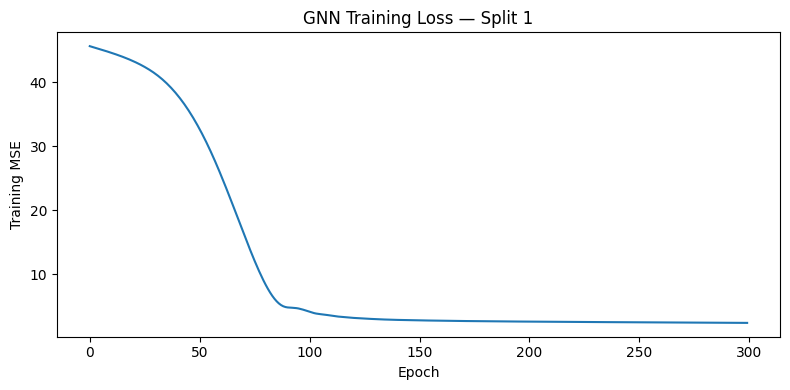

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("GNN Training Loss — Split 1")
plt.tight_layout()
plt.show()

## Five-split GNN evaluation

A single split is useful for debugging, but it is not enough to judge the model. I therefore evaluate the GNN across five location-level splits.

This is the point where I compare the graph approach more seriously with the earlier tabular models. I am looking for consistent out-of-sample performance across held-out breach locations rather than a good result from one particular split.


In [66]:
def build_split_node_features(train_location_ids):
    """
    Fit preprocessing only on training nodes,
    then transform all graph nodes.
    """

    train_mask = node_features_df["breach_id"].isin(
        train_location_ids
    )

    train_nodes = node_features_df.loc[
        train_mask
    ].copy()

    # -----------------------------
    # Numeric features
    # -----------------------------
    scaler = StandardScaler()

    scaler.fit(
        train_nodes[numeric_node_features]
    )

    X_num = scaler.transform(
        node_features_df[numeric_node_features]
    )

    # -----------------------------
    # Categorical features
    # -----------------------------
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    encoder.fit(
        train_nodes[categorical_node_features]
    )

    X_cat = encoder.transform(
        node_features_df[categorical_node_features]
    )

    X = np.hstack([
        X_num,
        X_cat
    ]).astype(np.float32)

    return torch.tensor(
        X,
        dtype=torch.float32
    )

In [67]:
gnn_results = []

for split_id, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):

    print(f"\n========== Split {split_id} ==========")

    # ----------------------------------
    # Location split
    # ----------------------------------
    train_location_ids = set(
        node_scenarios.iloc[
            train_idx
        ]["breach_id"]
    )

    test_location_ids = set(
        node_scenarios.iloc[
            test_idx
        ]["breach_id"]
    )

    train_obs = node_scenarios[
        node_scenarios["breach_id"].isin(
            train_location_ids
        )
    ].copy()

    test_obs = node_scenarios[
        node_scenarios["breach_id"].isin(
            test_location_ids
        )
    ].copy()

    # ----------------------------------
    # Split-specific node preprocessing
    # ----------------------------------
    x_split = build_split_node_features(
        train_location_ids
    ).to(device)

    # ----------------------------------
    # Split-specific RP scaling
    # ----------------------------------
    train_rp_log = np.log1p(
        train_obs["return_period"].astype(float)
    )

    rp_mean_split = float(
        train_rp_log.mean()
    )

    rp_std_split = float(
        train_rp_log.std()
    )

    def scale_rp_split(rp):
        rp_log = torch.log1p(
            torch.clamp(rp, min=0)
        )

        return (
            rp_log - rp_mean_split
        ) / (rp_std_split + 1e-8)

    # ----------------------------------
    # Model-specific forward function
    # ----------------------------------
    model = SimpleFloodGNN(
        input_dim=x_split.shape[1],
        hidden_dim=64
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0005,
        weight_decay=1e-4
    )

    # ----------------------------------
    # Train
    # ----------------------------------
    model.train()

    for epoch in range(1, 301):

        optimizer.zero_grad()

        total_loss = 0.0
        n_used = 0

        for rp in sorted(
            train_obs["return_period"].unique()
        ):

            target = build_target_vector(
                train_obs,
                rp,
                train_location_ids,
                node_order
            ).to(device)

            mask = torch.isfinite(target)

            if mask.sum() == 0:
                continue

            rp_tensor = torch.full(
                (graph.num_nodes,),
                float(rp),
                dtype=torch.float32,
                device=device
            )

            # Important:
            # use split-specific x
            pred = model(
                x_split,
                graph.edge_index,
                rp_tensor
            )

            loss = F.mse_loss(
                pred[mask],
                target[mask]
            )

            total_loss += loss
            n_used += 1

        total_loss = total_loss / n_used

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite loss in split {split_id}, "
                f"epoch {epoch}"
            )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        if epoch % 100 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {total_loss.item():.4f}"
            )

    # ----------------------------------
    # Test
    # ----------------------------------
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for rp in sorted(
            test_obs["return_period"].unique()
        ):

            test_rp = test_obs[
                test_obs["return_period"] == rp
            ]

            rp_tensor = torch.full(
                (graph.num_nodes,),
                float(rp),
                dtype=torch.float32,
                device=device
            )

            pred = model(
                x_split,
                graph.edge_index,
                rp_tensor
            )

            pred = pred.cpu().numpy()

            for _, row in test_rp.iterrows():

                idx = node_to_idx[
                    row["breach_id"]
                ]

                predictions.append(
                    pred[idx]
                )

                actuals.append(
                    row["log_damage"]
                )

    gnn_results.append({
        "split": split_id,
        "MAE": mean_absolute_error(
            actuals,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actuals,
                predictions
            )
        ),
        "R2": r2_score(
            actuals,
            predictions
        )
    })

gnn_results = pd.DataFrame(
    gnn_results
)

print("\nGNN results:")
print(gnn_results)

print("\nMean:")
print(
    gnn_results[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

print("\nStd:")
print(
    gnn_results[
        ["MAE", "RMSE", "R2"]
    ].std()
)


========== Split 1 ==========
Epoch 100 | Loss: 6.3353
Epoch 200 | Loss: 2.6736
Epoch 300 | Loss: 2.4699

========== Split 2 ==========
Epoch 100 | Loss: 4.7025
Epoch 200 | Loss: 2.4253
Epoch 300 | Loss: 2.2785

========== Split 3 ==========
Epoch 100 | Loss: 4.7077
Epoch 200 | Loss: 2.4199
Epoch 300 | Loss: 2.2148

========== Split 4 ==========
Epoch 100 | Loss: 5.0361
Epoch 200 | Loss: 2.4912
Epoch 300 | Loss: 2.3234

========== Split 5 ==========
Epoch 100 | Loss: 4.7008
Epoch 200 | Loss: 2.3660
Epoch 300 | Loss: 2.1789

GNN results:
   split       MAE      RMSE        R2
0      1  1.178523  1.487903  0.558309
1      2  1.332839  1.738061  0.450714
2      3  1.344643  1.731093  0.429628
3      4  1.274530  1.606567  0.514298
4      5  1.432002  1.818699  0.461186

Mean:
MAE     1.312507
RMSE    1.676464
R2      0.482827
dtype: float64

Std:
MAE     0.093700
RMSE    0.129856
R2      0.052483
dtype: float64


### What the first GNN experiment told me

The graph representation by itself did not provide enough additional predictive information to outperform the strongest tabular/exogenous benchmark.

I therefore do not interpret the GNN as a better predictor simply because the problem has a graph structure. Instead, this result suggests that the **way the relationships are encoded in the graph matters**, so I next test whether explicit edge attributes can give the model more useful information about spatial and system relationships.


## Next: GNN with edge attributes

The previous model mainly used the graph topology to pass messages. I now add the actual relationship information I constructed earlier: distance weight, shared river, and shared dike ring.

This is a direct response to the previous result. If system structure contains information that topology alone does not express, the edge-aware model should have access to it explicitly.


### Define the edge-aware model

The edge-aware model allows the message-passing layers to use both node features and edge attributes.

I am testing whether this richer representation can make the graph more informative without changing the basic prediction task.


In [68]:
from torch_geometric.nn import GATv2Conv


class EdgeAwareFloodGNN(nn.Module):

    def __init__(
        self,
        input_dim,
        edge_dim=3,
        hidden_dim=64,
        heads=4
    ):
        super().__init__()

        self.conv1 = GATv2Conv(
            input_dim,
            hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=edge_dim,
            add_self_loops=False
        )

        self.conv2 = GATv2Conv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            edge_dim=edge_dim,
            add_self_loops=False
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim + 1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        return_period
    ):

        h = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        h = self.conv2(
            h,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        rp_feature = scale_rp_split(
            return_period
        ).reshape(-1, 1)

        h = torch.cat(
            [h, rp_feature],
            dim=1
        )

        return self.regressor(h).squeeze(-1)

### 2. Normalize the edge attributes

The edge attributes have different meanings and scales, so I standardize them before passing them into the model.

This is a preprocessing step rather than a new modelling assumption; the goal is to keep one feature from dominating because of its numerical scale.


In [70]:
edge_attr = torch.tensor(
    all_edges[
        [
            "distance_weight",
            "same_river",
            "same_dijkring"
        ]
    ].to_numpy(),
    dtype=torch.float32
).to(device)

print("Edge attributes:", edge_attr.shape)
print("Finite:", torch.isfinite(edge_attr).all().item())
print("Min:", edge_attr.min().item())
print("Max:", edge_attr.max().item())

Edge attributes: torch.Size([25956, 3])
Finite: True
Min: 0.0
Max: 1.0


### 3. Train Split 1 first

I first train the edge-aware model on the same Split 1 setup.

As before, I use the single split mainly as a sanity check before relying on the full five-split evaluation.


In [71]:
# Split 1
train_idx, test_idx = splits[0]

train_location_ids = set(
    node_scenarios.iloc[train_idx]["breach_id"]
)

test_location_ids = set(
    node_scenarios.iloc[test_idx]["breach_id"]
)

train_obs = node_scenarios[
    node_scenarios["breach_id"].isin(
        train_location_ids
    )
].copy()

test_obs = node_scenarios[
    node_scenarios["breach_id"].isin(
        test_location_ids
    )
].copy()

# Split-specific node preprocessing
x_split = build_split_node_features(
    train_location_ids
).to(device)

# Split-specific return-period scaling
train_rp_log = np.log1p(
    train_obs["return_period"].astype(float)
)

rp_mean_split = float(
    train_rp_log.mean()
)

rp_std_split = float(
    train_rp_log.std()
)

def scale_rp_split(rp):

    rp = torch.clamp(
        rp,
        min=0
    )

    return (
        torch.log1p(rp) - rp_mean_split
    ) / (rp_std_split + 1e-8)

print("Train locations:", len(train_location_ids))
print("Test locations:", len(test_location_ids))

Train locations: 475
Test locations: 119


### 4. New model and training

I train the edge-aware GNN using the corrected location-level target setup.

The question is whether explicitly supplying spatial and hydraulic-system relationships as edge attributes improves generalization compared with topology-only message passing.


In [75]:
edge_gnn = EdgeAwareFloodGNN(
    input_dim=x_split.shape[1],
    edge_dim=3,
    hidden_dim=64,
    heads=4
).to(device)

optimizer = torch.optim.Adam(
    edge_gnn.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

edge_gnn_losses = []

for epoch in range(1, 301):

    edge_gnn.train()
    optimizer.zero_grad()

    total_loss = 0.0
    n_used = 0

    for rp in sorted(
        train_obs["return_period"].unique()
    ):

        target = build_target_vector(
            train_obs,
            rp,
            train_location_ids,
            node_order
        ).to(device)

        mask = torch.isfinite(target)

        if mask.sum() == 0:
            continue

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = edge_gnn(
            x_split,
            graph.edge_index,
            edge_attr,
            rp_tensor
        )

        loss = F.mse_loss(
            pred[mask],
            target[mask]
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch}, RP {rp}"
            )

        total_loss += loss
        n_used += 1

    total_loss = total_loss / n_used

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        edge_gnn.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    edge_gnn_losses.append(
        total_loss.item()
    )

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {total_loss.item():.4f}"
        )

Epoch 050 | Loss: 36.1854
Epoch 100 | Loss: 8.4568
Epoch 150 | Loss: 3.0070
Epoch 200 | Loss: 2.4552
Epoch 250 | Loss: 2.1288
Epoch 300 | Loss: 1.9122


### 5. Evaluate Split 1

I evaluate the edge-aware model on the held-out breach locations from Split 1.

I compare this result with the topology-only GNN before moving back to the five-split evaluation, so that any improvement can be linked to the addition of edge information rather than to a different train/test setup.


In [76]:
edge_gnn.eval()

predictions = []
actuals = []

with torch.no_grad():

    for rp in sorted(
        test_obs["return_period"].unique()
    ):

        test_rp = test_obs[
            test_obs["return_period"] == rp
        ]

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = edge_gnn(
            x_split,
            graph.edge_index,
            edge_attr,
            rp_tensor
        ).cpu().numpy()

        for _, row in test_rp.iterrows():

            idx = node_to_idx[
                row["breach_id"]
            ]

            predictions.append(
                pred[idx]
            )

            actuals.append(
                row["log_damage"]
            )

edge_gnn_mae = mean_absolute_error(
    actuals,
    predictions
)

edge_gnn_rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

edge_gnn_r2 = r2_score(
    actuals,
    predictions
)

print("Edge-aware GNN — Split 1")
print("------------------------")
print("MAE :", edge_gnn_mae)
print("RMSE:", edge_gnn_rmse)
print("R²  :", edge_gnn_r2)

Edge-aware GNN — Split 1
------------------------
MAE : 1.0848571687957977
RMSE: 1.359652024436843
R²  : 0.6311710845733527


In [77]:
edge_gnn_results = []

for split_id, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):

    print(f"\n========== Edge-GNN Split {split_id} ==========")

    # -----------------------------
    # Location split
    # -----------------------------
    train_location_ids = set(
        node_scenarios.iloc[train_idx]["breach_id"]
    )

    test_location_ids = set(
        node_scenarios.iloc[test_idx]["breach_id"]
    )

    train_obs = node_scenarios[
        node_scenarios["breach_id"].isin(
            train_location_ids
        )
    ].copy()

    test_obs = node_scenarios[
        node_scenarios["breach_id"].isin(
            test_location_ids
        )
    ].copy()

    # -----------------------------
    # Split-specific node features
    # -----------------------------
    x_split = build_split_node_features(
        train_location_ids
    ).to(device)

    # -----------------------------
    # Split-specific RP scaling
    # -----------------------------
    train_rp_log = np.log1p(
        train_obs["return_period"].astype(float)
    )

    rp_mean_split = float(
        train_rp_log.mean()
    )

    rp_std_split = float(
        train_rp_log.std()
    )

    def scale_rp_split(rp):
        rp = torch.clamp(rp, min=0)
        return (
            torch.log1p(rp) - rp_mean_split
        ) / (rp_std_split + 1e-8)

    # -----------------------------
    # Model
    # -----------------------------
    model = EdgeAwareFloodGNN(
        input_dim=x_split.shape[1],
        edge_dim=3,
        hidden_dim=64,
        heads=4
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0003,
        weight_decay=1e-4
    )

    # -----------------------------
    # Train
    # -----------------------------
    for epoch in range(1, 301):

        model.train()
        optimizer.zero_grad()

        total_loss = 0.0
        n_used = 0

        for rp in sorted(
            train_obs["return_period"].unique()
        ):

            target = build_target_vector(
                train_obs,
                rp,
                train_location_ids,
                node_order
            ).to(device)

            mask = torch.isfinite(target)

            if mask.sum() == 0:
                continue

            rp_tensor = torch.full(
                (graph.num_nodes,),
                float(rp),
                dtype=torch.float32,
                device=device
            )

            pred = model(
                x_split,
                graph.edge_index,
                edge_attr,
                rp_tensor
            )

            loss = F.mse_loss(
                pred[mask],
                target[mask]
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss at split {split_id}, "
                    f"epoch {epoch}, RP {rp}"
                )

            total_loss += loss
            n_used += 1

        total_loss = total_loss / n_used

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        if epoch % 100 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {total_loss.item():.4f}"
            )

    # -----------------------------
    # Test
    # -----------------------------
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for rp in sorted(
            test_obs["return_period"].unique()
        ):

            test_rp = test_obs[
                test_obs["return_period"] == rp
            ]

            rp_tensor = torch.full(
                (graph.num_nodes,),
                float(rp),
                dtype=torch.float32,
                device=device
            )

            pred = model(
                x_split,
                graph.edge_index,
                edge_attr,
                rp_tensor
            ).cpu().numpy()

            for _, row in test_rp.iterrows():

                idx = node_to_idx[
                    row["breach_id"]
                ]

                predictions.append(
                    pred[idx]
                )

                actuals.append(
                    row["log_damage"]
                )

    edge_gnn_results.append({
        "split": split_id,
        "MAE": mean_absolute_error(
            actuals,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actuals,
                predictions
            )
        ),
        "R2": r2_score(
            actuals,
            predictions
        )
    })

edge_gnn_results = pd.DataFrame(
    edge_gnn_results
)

print("\nEdge-aware GNN results:")
print(edge_gnn_results)

print("\nMean:")
print(
    edge_gnn_results[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

print("\nStd:")
print(
    edge_gnn_results[
        ["MAE", "RMSE", "R2"]
    ].std()
)


========== Edge-GNN Split 1 ==========
Epoch 100 | Loss: 10.7599
Epoch 200 | Loss: 2.3179
Epoch 300 | Loss: 1.8660

========== Edge-GNN Split 2 ==========
Epoch 100 | Loss: 7.7237
Epoch 200 | Loss: 2.2116
Epoch 300 | Loss: 1.6286

========== Edge-GNN Split 3 ==========
Epoch 100 | Loss: 6.8872
Epoch 200 | Loss: 2.2190
Epoch 300 | Loss: 1.6782

========== Edge-GNN Split 4 ==========
Epoch 100 | Loss: 6.5047
Epoch 200 | Loss: 2.1646
Epoch 300 | Loss: 1.7363

========== Edge-GNN Split 5 ==========
Epoch 100 | Loss: 4.4028
Epoch 200 | Loss: 1.9790
Epoch 300 | Loss: 1.5340

Edge-aware GNN results:
   split       MAE      RMSE        R2
0      1  1.130891  1.399185  0.609411
1      2  1.292816  1.693802  0.478332
2      3  1.274764  1.638775  0.488840
3      4  1.206981  1.588123  0.525385
4      5  1.364684  1.838894  0.449153

Mean:
MAE     1.254027
RMSE    1.631756
R2      0.510224
dtype: float64

Std:
MAE     0.088819
RMSE    0.160311
R2      0.061790
dtype: float64


## Interpretation

The edge-aware GNN improves on the topology-only graph model, which suggests that explicitly representing spatial, river, and dike-ring relationships gives the message-passing model useful additional information.

However, it still does not outperform the strongest tabular Random Forest benchmark. I therefore do not treat the GNN as the best predictive model. Instead, this experiment gives me a more useful result for the next stage: graph structure appears valuable as a **representation of dependence**, even when it is not the strongest standalone predictor of damage.


In [78]:
edge_gnn_results.to_csv(
    TABLE_DIR / "edge_gnn_5fold_results.csv",
    index=False
)

print(
    edge_gnn_results[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

MAE     1.254027
RMSE    1.631756
R2      0.510224
dtype: float64


In [79]:
# Spatial edges: already represented by the original 5-NN graph
spatial_only_edges = edges.copy()

# Spatial + dike-ring
spatial_dike_edges = pd.concat(
    [
        edges,
        system_edges[
            system_edges["same_dijkring"] == 1
        ]
    ],
    ignore_index=True
).drop_duplicates(
    subset=["source", "target"]
)

# Spatial + river + dike-ring
spatial_system_edges = pd.concat(
    [
        edges,
        system_edges
    ],
    ignore_index=True
).drop_duplicates(
    subset=["source", "target"]
)

print("Spatial only:", len(spatial_only_edges))
print("Spatial + dike:", len(spatial_dike_edges))
print("Spatial + all system:", len(spatial_system_edges))

Spatial only: 3050
Spatial + dike: 12443
Spatial + all system: 25956


### Training the GNN on the 3,050-edge spatial-only graph

I now isolate the spatial component of the graph to make the comparison more explicit.

By removing the additional system edges, I can test how much of the GNN behaviour comes from local spatial connectivity alone, rather than assuming that all graph relationships contribute equally.


In [ ]:

# Spatial-only graph


spatial_edges = spatial_only_edges.copy()

spatial_edges["distance_weight"] = np.exp(
    -spatial_edges["distance_km"] / 25.0
)

spatial_edge_index = torch.tensor(
    spatial_edges[
        ["source", "target"]
    ].to_numpy().T,
    dtype=torch.long
).to(device)

spatial_edge_attr = torch.tensor(
    spatial_edges[
        ["distance_weight"]
    ].to_numpy(),
    dtype=torch.float32
).to(device)

print("Spatial edge index:", spatial_edge_index.shape)
print("Spatial edge attributes:", spatial_edge_attr.shape)
print(
    "Finite:",
    torch.isfinite(spatial_edge_attr).all().item()
)

Spatial edge index: torch.Size([2, 3050])
Spatial edge attributes: torch.Size([3050, 1])
Finite: True


In [81]:
class SpatialFloodGNN(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4
    ):
        super().__init__()

        self.conv1 = GATv2Conv(
            input_dim,
            hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=1,
            add_self_loops=False
        )

        self.conv2 = GATv2Conv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            edge_dim=1,
            add_self_loops=False
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim + 1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        return_period
    ):

        h = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        h = self.conv2(
            h,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        rp_feature = scale_rp_split(
            return_period
        ).reshape(-1, 1)

        h = torch.cat(
            [h, rp_feature],
            dim=1
        )

        return self.regressor(h).squeeze(-1)

### Training Split 1 only

I use Split 1 here as a controlled comparison for the spatial-only graph.

The purpose is diagnostic: I want to see how a purely spatial graph compares with the richer edge-aware construction before interpreting the full set of results.


In [82]:
spatial_gnn = SpatialFloodGNN(
    input_dim=x_split.shape[1],
    hidden_dim=64,
    heads=4
).to(device)

optimizer = torch.optim.Adam(
    spatial_gnn.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

spatial_gnn_losses = []

for epoch in range(1, 301):

    spatial_gnn.train()
    optimizer.zero_grad()

    total_loss = 0.0
    n_used = 0

    for rp in sorted(
        train_obs["return_period"].unique()
    ):

        target = build_target_vector(
            train_obs,
            rp,
            train_location_ids,
            node_order
        ).to(device)

        mask = torch.isfinite(target)

        if mask.sum() == 0:
            continue

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = spatial_gnn(
            x_split,
            spatial_edge_index,
            spatial_edge_attr,
            rp_tensor
        )

        loss = F.mse_loss(
            pred[mask],
            target[mask]
        )

        total_loss += loss
        n_used += 1

    total_loss = total_loss / n_used

    if not torch.isfinite(total_loss):
        raise RuntimeError(
            f"Non-finite loss at epoch {epoch}"
        )

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        spatial_gnn.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    spatial_gnn_losses.append(
        total_loss.item()
    )

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {total_loss.item():.4f}"
        )

Epoch 050 | Loss: 29.0137
Epoch 100 | Loss: 3.9377
Epoch 150 | Loss: 1.9626
Epoch 200 | Loss: 1.6695
Epoch 250 | Loss: 1.4648
Epoch 300 | Loss: 1.2886


In [83]:
spatial_gnn.eval()

predictions = []
actuals = []

with torch.no_grad():

    for rp in sorted(
        test_obs["return_period"].unique()
    ):

        test_rp = test_obs[
            test_obs["return_period"] == rp
        ]

        rp_tensor = torch.full(
            (graph.num_nodes,),
            float(rp),
            dtype=torch.float32,
            device=device
        )

        pred = spatial_gnn(
            x_split,
            spatial_edge_index,
            spatial_edge_attr,
            rp_tensor
        ).cpu().numpy()

        for _, row in test_rp.iterrows():

            idx = node_to_idx[
                row["breach_id"]
            ]

            predictions.append(pred[idx])
            actuals.append(row["log_damage"])

print("Spatial-only GNN — Split 1")
print("--------------------------")
print(
    "MAE :",
    mean_absolute_error(actuals, predictions)
)
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            actuals,
            predictions
        )
    )
)
print(
    "R²  :",
    r2_score(actuals, predictions)
)

Spatial-only GNN — Split 1
--------------------------
MAE : 1.2941922037598155
RMSE: 1.7200698022106888
R²  : 0.5180417892041793


### What this comparison adds

A learned GNN does not automatically improve on a well-designed spatial interpolation baseline.

For this dataset, the important takeaway is therefore not that a particular neural architecture wins, but that different representations capture different parts of the problem. This supports the direction I take later: use graph learning where it can represent spatial and system dependence, while being careful not to assume that graph neural networks are automatically superior predictors.
